<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/03_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Dimensionality Reduction Techniques

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 3 membahas teknik-teknik reduksi dimensi yang digunakan untuk menyederhanakan dataset dengan dimensi tinggi, sambil mempertahankan informasi yang relevan sebanyak mungkin. Reduksi dimensi membantu mengurangi kompleksitas komputasi, meningkatkan performa model, dan memudahkan visualisasi data.

### Topik yang Dibahas:
1. Pengantar reduksi dimensi dan mengapa hal ini penting
2. PCA (Principal Component Analysis): transformasi dataset
3. LDA (Linear Discriminant Analysis): memaksimalkan separabilitas kelas
4. t-SNE: visualisasi data berdimensi tinggi
5. Panduan memilih teknik yang tepat
6. Dampak reduksi dimensi terhadap performa model

## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Pengantar Reduksi Dimensi

### Penjelasan Teori

**Reduksi dimensi (dimensionality reduction)** adalah proses mengurangi jumlah fitur (atau dimensi) dalam sebuah dataset sambil mempertahankan sebanyak mungkin informasi yang relevan.

**Mengapa reduksi dimensi sangat penting:**

1. **Menyederhanakan data:** Dataset berdimensi tinggi sulit divisualisasikan dan dianalisis. Dengan mengurangi jumlah fitur, data menjadi lebih mudah diinterpretasikan.

2. **Mengurangi biaya komputasi:** Lebih sedikit fitur berarti kebutuhan komputasi yang lebih rendah untuk melatih model ML, menghasilkan waktu training yang lebih cepat.

3. **Meningkatkan performa model:** Data berdimensi tinggi dapat menyebabkan overfitting, di mana model mempelajari noise daripada pola yang mendasarinya. Reduksi dimensi membantu memitigasi risiko ini.

4. **Meningkatkan visualisasi:** Banyak teknik visualisasi terbatas pada dua atau tiga dimensi. Reduksi dimensi memungkinkan proyeksi data berdimensi tinggi ke dimensi yang lebih rendah.

**Dua kategori utama teknik reduksi dimensi:**

- **Feature Selection (Seleksi Fitur):** Memilih subset fitur yang relevan dari dataset asli tanpa mentransformasinya. Metode: Filter, Wrapper, Embedded.
- **Feature Extraction (Ekstraksi Fitur):** Mentransformasi fitur asli ke ruang baru dengan dimensi lebih sedikit sambil mempertahankan informasi esensial. Contoh: PCA, LDA, t-SNE.

## 2. Transformasi Dataset dengan PCA (Principal Component Analysis)

### Penjelasan Teori

**PCA** adalah salah satu teknik reduksi dimensi yang paling banyak digunakan. PCA membantu menyederhanakan dataset dengan mentransformasikannya ke sistem koordinat baru, di mana variasi terbesar dalam data ditangkap oleh beberapa dimensi pertama, yang disebut **principal components**.

**Langkah-langkah kerja PCA:**

1. **Standardisasi:** PCA sangat sensitif terhadap varians variabel asli, sehingga penting untuk menstandarisasi data (mean=0, varians=1) sebelum menerapkan PCA.

2. **Komputasi matriks kovariansi:** Matriks kovariansi menangkap seberapa banyak dimensi bervariasi dari mean terhadap satu sama lain.

3. **Kalkulasi eigenvalue dan eigenvector:** Eigenvalue menunjukkan jumlah varians yang ditangkap oleh setiap principal component, sedangkan eigenvector merepresentasikan arah komponen tersebut.

4. **Pemilihan principal components:** Dengan memilih subset principal components berdasarkan eigenvalue-nya, kita dapat mengurangi dimensionalitas dataset sambil mempertahankan sebagian besar variansnya.

5. **Transformasi data:** Data asli diproyeksikan ke principal components yang dipilih untuk mendapatkan representasi yang tereduksi.

> **Catatan penting:** PCA adalah metode **unsupervised**, artinya tidak mempertimbangkan label kelas saat mengurangi dimensi. PCA berfokus pada memaksimalkan varians, bukan separabilitas kelas.

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

np.random.seed(2024)

# Load dataset Wine
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target

print(f"Shape dataset wine: {df_wine.shape}")
print(f"Jumlah kelas: {len(np.unique(target_wine))} ({wine.target_names})")
print()
print("5 baris pertama dataset:")
display(df_wine.head())

Shape dataset wine: (178, 13)
Jumlah kelas: 3 (['class_0' 'class_1' 'class_2'])

5 baris pertama dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Membuat pipeline PCA: standardisasi -> PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Selalu scale sebelum PCA
    ('pca', PCA(n_components=2))   # Reduksi ke 2 dimensi
])

# Fit dan transform data wine
X_pca = pca_pipeline.fit_transform(df_wine)

print(f"Shape sebelum PCA: {df_wine.shape}")
print(f"Shape setelah PCA: {X_pca.shape}")


Shape sebelum PCA: (178, 13)
Shape setelah PCA: (178, 2)


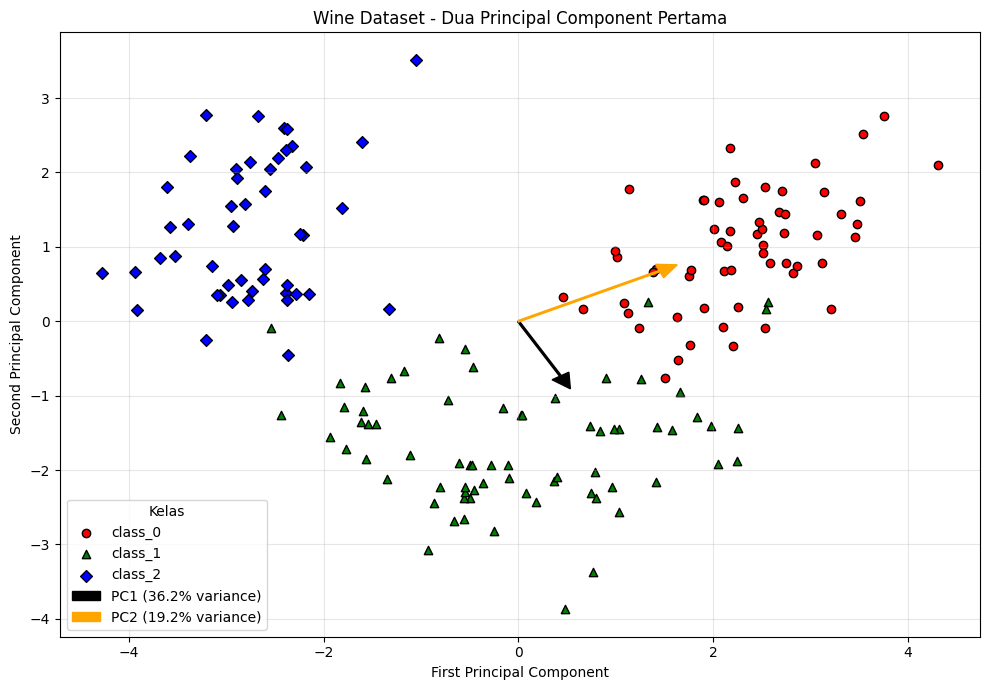

In [4]:
# Visualisasi hasil PCA
plt.figure(figsize=(10, 7))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(
        X_pca[target_wine == i, 0],
        X_pca[target_wine == i, 1],
        c=color, marker=shape,
        label=wine.target_names[i], edgecolors='black'
    )

# Dapatkan komponen PCA dan plot sebagai vektor
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)
arrow_colors = ['black', 'orange']
scaling = 3

for i, (component, ratio) in enumerate(zip(
    pca.components_, pca.explained_variance_ratio_
)):
    plt.arrow(
        origin[0], origin[1],
        component[0] * scaling, component[1] * scaling,
        color=arrow_colors[i], width=0.02,
        head_width=0.2, head_length=0.2,
        label=f'PC{i+1} ({ratio:.1%} variance)'
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - Dua Principal Component Pertama')
plt.legend(title="Kelas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

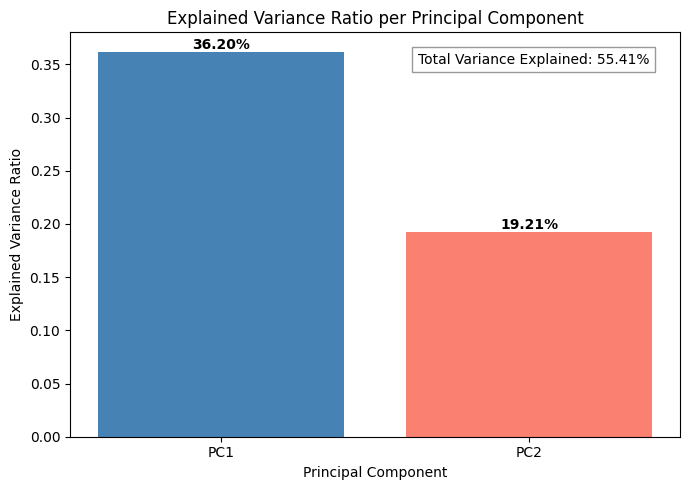

PC1 menjelaskan: 36.20% varians
PC2 menjelaskan: 19.21% varians
Total (PC1+PC2): 55.41% varians


In [5]:
# Analisis explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance_ratio)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(1, len(explained_variance_ratio) + 1)
bars = ax.bar(x, explained_variance_ratio, color=['steelblue', 'salmon'])

# Tambahkan label persentase pada bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height, f'{height:.2%}',
        ha='center', va='bottom', fontweight='bold'
    )

# Tambahkan teks total varians
ax.text(
    0.95, 0.95,
    f'Total Variance Explained: {cumulative_variance:.2%}',
    transform=ax.transAxes, ha='right', va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio per Principal Component')
plt.tight_layout()
plt.show()

print(f"PC1 menjelaskan: {explained_variance_ratio[0]:.2%} varians")
print(f"PC2 menjelaskan: {explained_variance_ratio[1]:.2%} varians")
print(f"Total (PC1+PC2): {cumulative_variance:.2%} varians")

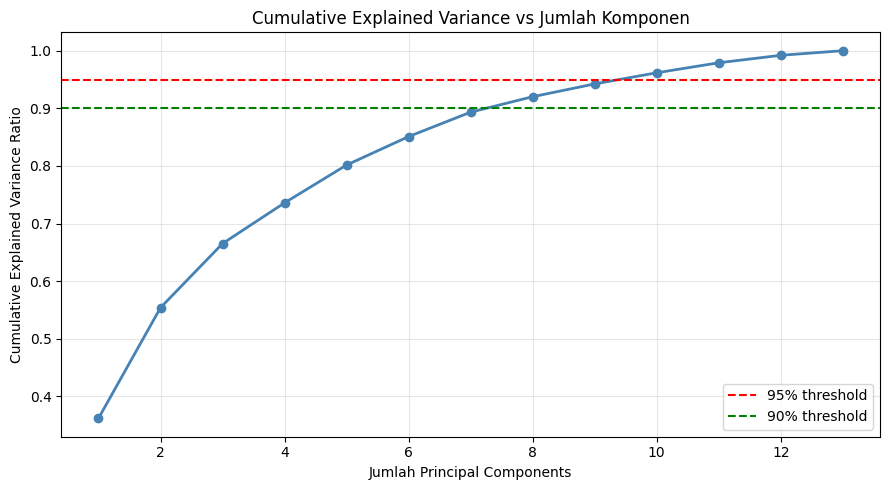

Jumlah komponen untuk menjelaskan >= 95% varians: 10


In [6]:
# Menentukan jumlah komponen optimal dengan cumulative explained variance
pca_full = PCA()
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(df_wine)
pca_full.fit(X_scaled_full)

cumulative_variance_full = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance_full) + 1),
    cumulative_variance_full,
    marker='o', color='steelblue', linewidth=2
)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% threshold')
plt.xlabel('Jumlah Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance vs Jumlah Komponen')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance_full >= 0.95) + 1
print(f"Jumlah komponen untuk menjelaskan >= 95% varians: {n_components_95}")

## 3. Memaksimalkan Separabilitas Kelas dengan LDA (Linear Discriminant Analysis)

### Penjelasan Teori

**LDA** adalah teknik reduksi dimensi yang sangat berguna untuk tugas supervised learning, terutama dalam masalah klasifikasi. Berbeda dengan PCA yang berfokus pada memaksimalkan varians di semua titik data tanpa mempertimbangkan label kelas, LDA bertujuan untuk **memaksimalkan separabilitas kelas**.

**Tujuan utama LDA:**

1. **Memaksimalkan separabilitas kelas:** LDA mengidentifikasi sumbu yang memaksimalkan jarak antara kelas yang berbeda sambil meminimalkan varians di dalam setiap kelas. Ini meningkatkan kemampuan diskriminatif fitur.

2. **Reduksi dimensi:** Dengan memproyeksikan data ke ruang berdimensi rendah yang didefinisikan oleh linear discriminants, LDA mengurangi kompleksitas dataset sambil mempertahankan informasi yang penting untuk klasifikasi.

3. **Asumsi:** LDA mengasumsikan bahwa data untuk setiap kelas mengikuti distribusi Gaussian (normal) dengan matriks kovariansi bersama. Ini adalah alasan mengapa standardisasi diterapkan sebelum LDA.

**Perbedaan kunci PCA vs LDA:**

| Aspek | PCA | LDA |
|-------|-----|-----|
| Tipe | Unsupervised | Supervised |
| Tujuan | Memaksimalkan varians | Memaksimalkan separabilitas kelas |
| Output | Principal components (orthogonal) | Linear discriminants |
| Penggunaan | Eksplorasi data, pengurangan noise | Klasifikasi, feature extraction |

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pisahkan fitur dan target wine
X_wine, y_wine = wine.data, wine.target

# Buat pipeline LDA: standardisasi -> LDA
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))
    # max komponen = min(n_features, n_classes - 1) = min(13, 2) = 2
])

# Fit dan transform data wine
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

print(f"Shape sebelum LDA: {X_wine.shape}")
print(f"Shape setelah LDA: {X_lda_wine.shape}")

Shape sebelum LDA: (178, 13)
Shape setelah LDA: (178, 2)


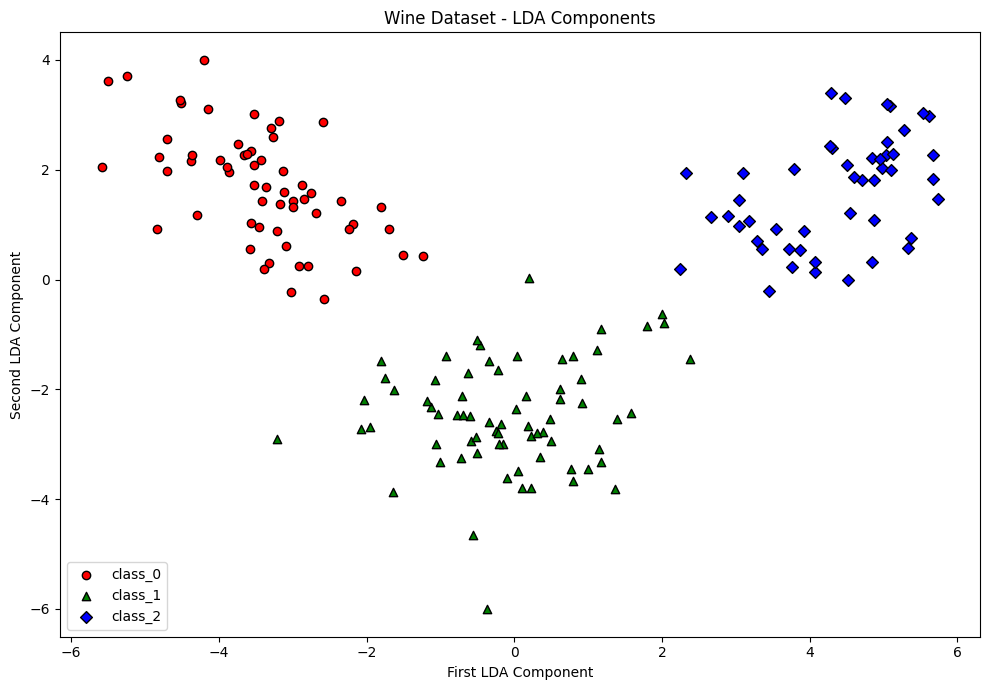

In [8]:
# Visualisasi transformasi LDA
plt.figure(figsize=(10, 7))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.tight_layout()
plt.show()

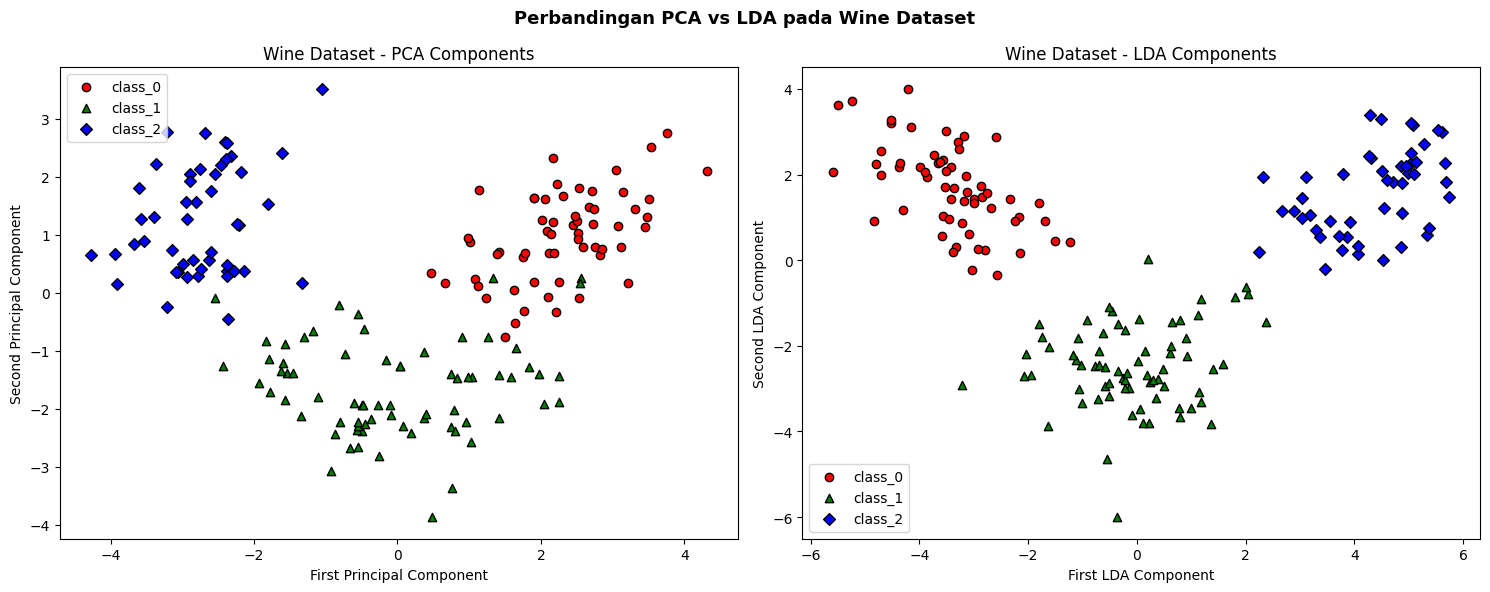

Pengamatan:
  LDA menunjukkan separabilitas kelas yang lebih baik karena menggunakan
  informasi label kelas (supervised) selama proses transformasi.


In [9]:
# Perbandingan PCA vs LDA side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    # PCA
    ax1.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )
    # LDA
    ax2.scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )

ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
ax1.set_title('Wine Dataset - PCA Components')
ax1.legend()

ax2.set_xlabel('First LDA Component')
ax2.set_ylabel('Second LDA Component')
ax2.set_title('Wine Dataset - LDA Components')
ax2.legend()

plt.suptitle('Perbandingan PCA vs LDA pada Wine Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Pengamatan:")
print("  LDA menunjukkan separabilitas kelas yang lebih baik karena menggunakan")
print("  informasi label kelas (supervised) selama proses transformasi.")

## 4. t-SNE dan Visualisasi Data

### Penjelasan Teori

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** adalah teknik untuk memvisualisasikan data berdimensi tinggi dengan memetakannya ke ruang berdimensi rendah, biasanya dua atau tiga dimensi. Metode ini sangat efektif untuk mengungkap struktur yang mendasari dataset yang kompleks.

**Bagaimana t-SNE bekerja:**

1. **Pairwise similarities:** t-SNE pertama-tama menghitung kesamaan (similarity) berpasangan antara titik data berdimensi tinggi. Titik yang serupa mendapat probabilitas lebih tinggi, sedangkan titik yang tidak serupa mendapat probabilitas lebih rendah.

2. **Low-dimensional mapping:** t-SNE kemudian mencoba menemukan representasi berdimensi rendah dari data yang mempertahankan kesamaan ini sedekat mungkin.

3. **Cluster formation:** Hasilnya adalah visualisasi di mana titik data yang serupa dikelompokkan berdekatan, sementara titik yang tidak serupa dipisahkan lebih jauh.

**Perbedaan utama t-SNE vs PCA dan LDA:**

- t-SNE adalah teknik **non-linear**, sedangkan PCA dan LDA bersifat linear.
- t-SNE terutama digunakan untuk **visualisasi**, bukan untuk menghasilkan fitur yang digunakan dalam model ML.
- t-SNE dapat **komputasi intensif**, terutama untuk dataset besar.
- Hasil t-SNE **tidak dapat diinterpretasikan** secara langsung dalam hal kontribusi fitur, tidak seperti PCA.

> **Perhatian:** t-SNE adalah alat visualisasi, bukan alat feature extraction untuk model prediktif. Selalu scale data sebelum menerapkan t-SNE.

Shape dataset digits: (1797, 64)
Jumlah kelas: 10 ([0 1 2 3 4 5 6 7 8 9])
Setiap gambar berukuran: 8x8 piksel = 64 fitur


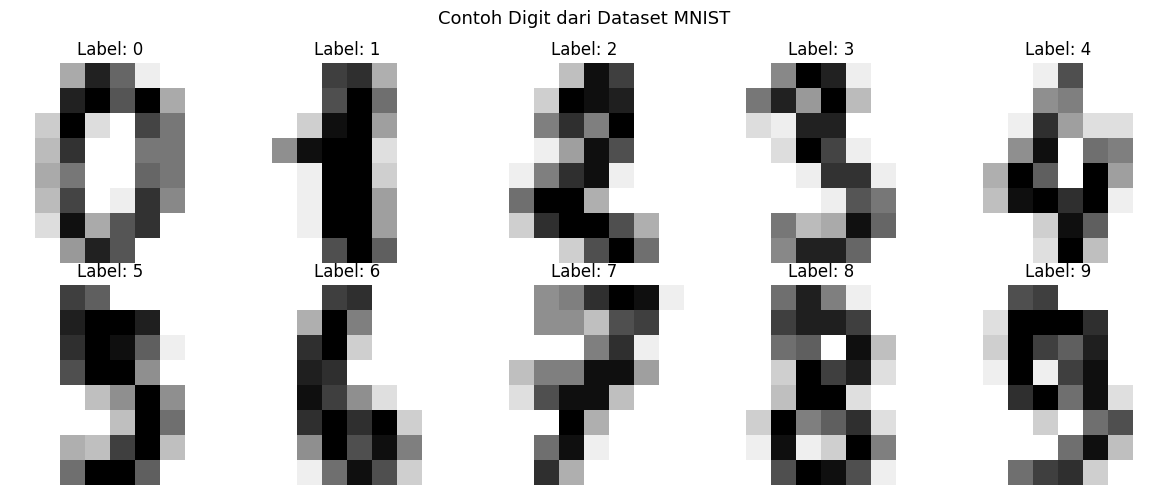

In [10]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# Load dataset MNIST digits
digits = load_digits()

print(f"Shape dataset digits: {digits.data.shape}")
print(f"Jumlah kelas: {len(np.unique(digits.target))} ({np.unique(digits.target)})")
print(f"Setiap gambar berukuran: 8x8 piksel = 64 fitur")

# Tampilkan beberapa contoh digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Contoh Digit dari Dataset MNIST', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Membuat pipeline t-SNE: standardisasi -> t-SNE
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024, perplexity=30))
])

# Fit dan transform data digits (gunakan subset untuk kecepatan)
print("Menjalankan t-SNE (mungkin memakan waktu beberapa detik)...")
X_tsne = tsne_pipeline.fit_transform(digits.data)
print(f"Shape setelah t-SNE: {X_tsne.shape}")

Menjalankan t-SNE (mungkin memakan waktu beberapa detik)...
Shape setelah t-SNE: (1797, 2)


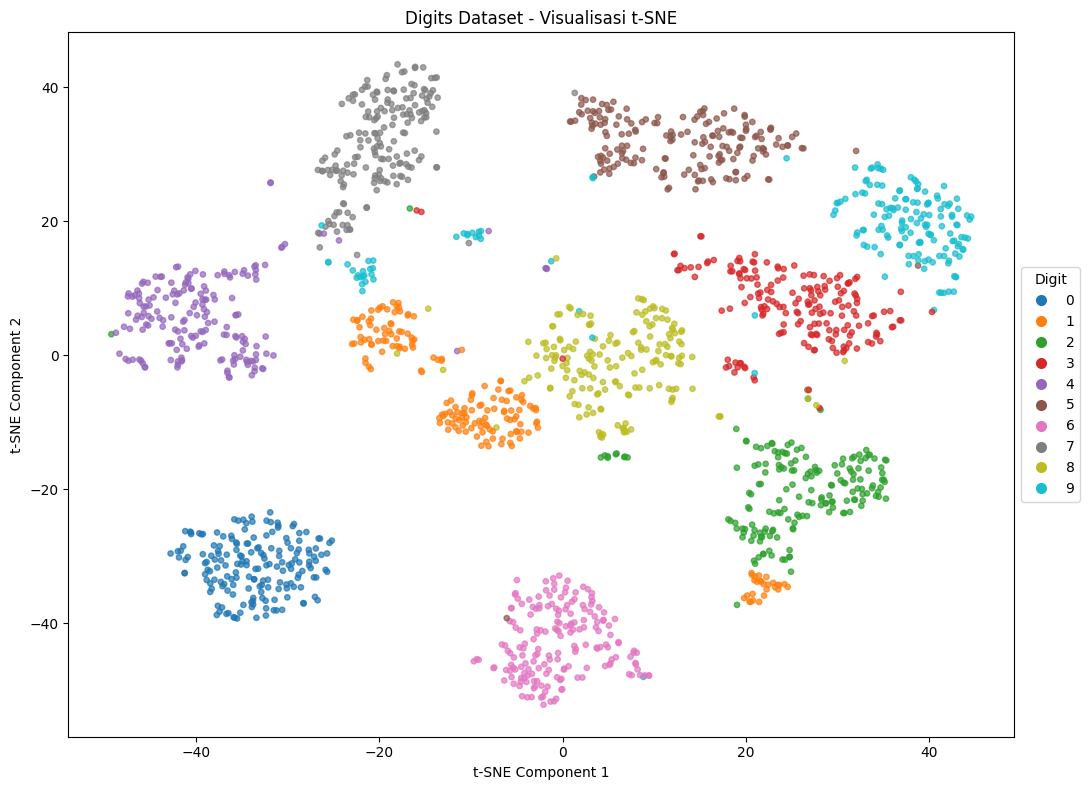

Pengamatan dari visualisasi t-SNE:
  - Digit '0' terisolasi karena tidak menyerupai digit lain secara visual.
  - Digit '4', '7', dan '9' berdekatan karena ditulis dengan cara yang serupa.
  - t-SNE berhasil mengelompokkan digit yang serupa menjadi cluster yang jelas.


In [12]:
# Visualisasi hasil t-SNE
plt.figure(figsize=(11, 8))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=digits.target, cmap='tab10',
    alpha=0.7, s=15
)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - Visualisasi t-SNE')

# Buat legenda
legend_elements = [
    plt.Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=plt.cm.tab10(i / 9),
        label=str(i), markersize=9
    )
    for i in range(10)
]
plt.legend(
    handles=legend_elements,
    title='Digit', loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()
plt.show()

print("Pengamatan dari visualisasi t-SNE:")
print("  - Digit '0' terisolasi karena tidak menyerupai digit lain secara visual.")
print("  - Digit '4', '7', dan '9' berdekatan karena ditulis dengan cara yang serupa.")
print("  - t-SNE berhasil mengelompokkan digit yang serupa menjadi cluster yang jelas.")

## 5. Memilih Teknik yang Tepat

### Penjelasan Teori

Memilih teknik reduksi dimensi yang tepat sangat penting untuk mengelola dataset berdimensi tinggi secara efektif. Pertimbangkan faktor-faktor berikut:

**Panduan Pemilihan:**

| Faktor | PCA | LDA | t-SNE |
|--------|-----|-----|-------|
| Jenis pembelajaran | Unsupervised | Supervised | Keduanya |
| Tujuan utama | Retain variance | Maximize class separation | Visualization |
| Linearitas | Linear | Linear | Non-linear |
| Skalabilitas | Tinggi | Sedang | Rendah |
| Interpretabilitas | Sedang | Sedang | Rendah |
| Output dapat digunakan untuk model | Ya | Ya | Tidak disarankan |

**Kapan menggunakan masing-masing:**
- Gunakan **PCA** untuk eksplorasi data awal, pengurangan noise, atau ketika label kelas tidak tersedia.
- Gunakan **LDA** ketika Anda memiliki data berlabel dan ingin memaksimalkan pemisahan antar kelas.
- Gunakan **t-SNE** hanya untuk visualisasi, untuk memahami struktur dan cluster dalam data berdimensi tinggi.

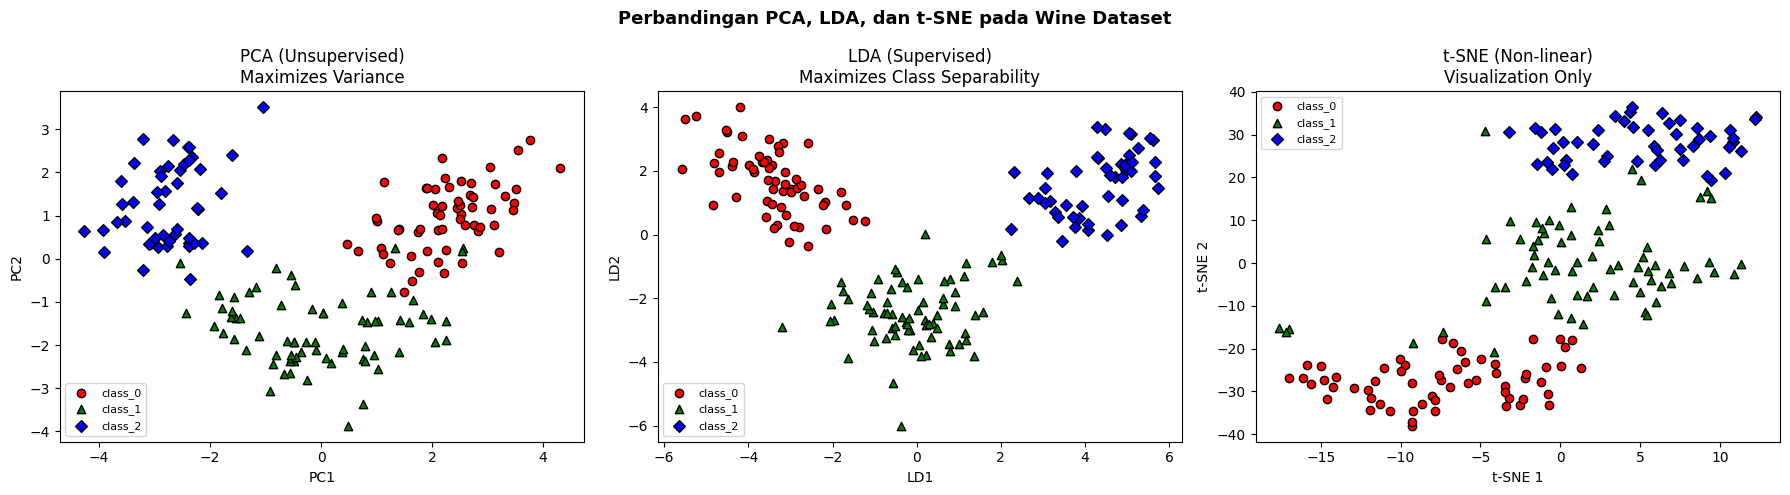

In [13]:
# Perbandingan komprehensif ketiga teknik pada dataset wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PCA
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, marker=shape, edgecolor='k',
        label=wine.target_names[i]
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA (Unsupervised)\nMaximizes Variance')
axes[0].legend(fontsize=8)

# 2. LDA
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    axes[1].scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='k',
        label=wine.target_names[i]
    )
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('LDA (Supervised)\nMaximizes Class Separability')
axes[1].legend(fontsize=8)

# 3. t-SNE pada wine dataset
tsne_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024, perplexity=15))
])
X_tsne_wine = tsne_wine.fit_transform(df_wine)

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[2].scatter(
        X_tsne_wine[mask, 0], X_tsne_wine[mask, 1],
        c=color, marker=shape, edgecolor='k',
        label=wine.target_names[i]
    )
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].set_title('t-SNE (Non-linear)\nVisualization Only')
axes[2].legend(fontsize=8)

plt.suptitle('Perbandingan PCA, LDA, dan t-SNE pada Wine Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Dampak Reduksi Dimensi terhadap Performa Model

### Penjelasan Teori

Reduksi dimensi tidak hanya membantu visualisasi, tetapi juga dapat berdampak signifikan terhadap performa model ML:

**Manfaat:**
- Mengurangi overfitting dengan menghilangkan fitur yang tidak informatif atau redundan.
- Mempercepat waktu training karena lebih sedikit fitur yang perlu diproses.
- Dapat meningkatkan akurasi dengan mengurangi noise.

**Risiko:**
- Kehilangan informasi: Reduksi dimensi yang berlebihan dapat menghilangkan informasi yang berharga.
- Interpretabilitas berkurang: Fitur yang ditransformasi (seperti principal components) lebih sulit diinterpretasikan dibandingkan fitur asli.
- Waktu komputasi tambahan: Proses transformasi itu sendiri membutuhkan waktu.

**Praktik terbaik:**
- Selalu evaluasi model dengan dan tanpa reduksi dimensi menggunakan cross-validation.
- Pilih jumlah komponen berdasarkan explained variance ratio (untuk PCA) atau performa cross-validation.
- Terapkan reduksi dimensi hanya pada data training, lalu gunakan transformer yang sama pada data testing.

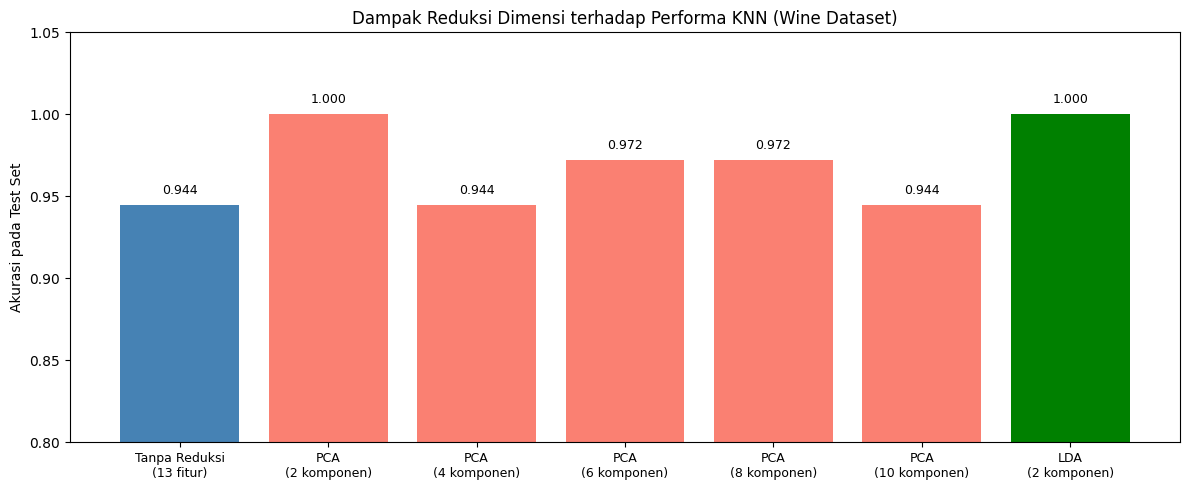

Catatan: Performa dapat bervariasi tergantung pada dataset dan algoritma yang digunakan.


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluasi dampak PCA terhadap performa model KNN pada wine dataset
X_wine_full = wine.data
y_wine_full = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X_wine_full, y_wine_full, test_size=0.2, random_state=42
)

results = {}

# 1. Tanpa reduksi dimensi
knn = KNeighborsClassifier(n_neighbors=5)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train)
results['Tanpa Reduksi\n(13 fitur)'] = knn.score(X_test_scaled, y_test)

# 2. Dengan PCA - berbagai jumlah komponen
for n_comp in [2, 4, 6, 8, 10]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe.fit(X_train, y_train)
    results[f'PCA\n({n_comp} komponen)'] = pipe.score(X_test, y_test)

# 3. Dengan LDA
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe_lda.fit(X_train, y_train)
results['LDA\n(2 komponen)'] = pipe_lda.score(X_test, y_test)

# Visualisasi hasil
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = range(len(results))
bars = ax.bar(x_pos, results.values(),
              color=['steelblue'] + ['salmon'] * 5 + ['green'])

for bar, val in zip(bars, results.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}', ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(results.keys(), fontsize=9)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Akurasi pada Test Set')
ax.set_title('Dampak Reduksi Dimensi terhadap Performa KNN (Wine Dataset)')
plt.tight_layout()
plt.show()

print("Catatan: Performa dapat bervariasi tergantung pada dataset dan algoritma yang digunakan.")

## Ringkasan Chapter 3

| Teknik | Kelas scikit-learn | Tipe | Tujuan Utama |
|--------|-------------------|------|-------------|
| PCA | `PCA()` | Unsupervised | Memaksimalkan varians yang dipertahankan |
| LDA | `LinearDiscriminantAnalysis()` | Supervised | Memaksimalkan separabilitas kelas |
| t-SNE | `TSNE()` | Semi-supervised | Visualisasi data berdimensi tinggi |

### Poin Kunci untuk Diingat:

1. **Selalu standardisasi data** sebelum menerapkan teknik reduksi dimensi (PCA, LDA, t-SNE), karena semua teknik ini sensitif terhadap skala fitur.

2. **PCA vs LDA:** Gunakan PCA ketika tidak memiliki label kelas (exploratory analysis); gunakan LDA ketika memiliki label kelas dan ingin memaksimalkan pemisahan antar kelas.

3. **t-SNE hanya untuk visualisasi:** Jangan gunakan t-SNE sebagai langkah preprocessing untuk model ML karena tidak deterministik dan tidak dapat diterapkan pada data baru tanpa retraining.

4. **Pilih jumlah komponen PCA** berdasarkan cumulative explained variance ratio. Biasanya mempertahankan 90-95% varians adalah titik awal yang baik.

5. **Integrasikan dalam Pipeline:** Gunakan `Pipeline()` untuk memastikan reduksi dimensi diterapkan secara konsisten pada data training dan testing, mencegah data leakage.

6. **Evaluasi dampak** reduksi dimensi dengan membandingkan performa model dengan dan tanpa reduksi dimensi menggunakan cross-validation.